A Time Series Forecasting Study of Gold Prices Using Machine Learning and Deep Learning Techniques Final Project

In [1]:
# Dataset Extraction: Gold Prices (GC=F)
# Time period: January 2010 to December 2025

import yfinance as yf
import pandas as pd

# Define ticker and date range
ticker = "GC=F"   # Gold Futures
start_date = "2010-01-01"
end_date = "2025-12-31"

# Download data
df = yf.download(ticker, start=start_date, end=end_date)

# Reset index to make Date a column
df.reset_index(inplace=True)

# Save to CSV
file_name = "Gold_GC_F_2010_2025.csv"
df.to_csv(file_name, index=False)

# Basic verification
print("Gold dataset downloaded successfully!")
print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("Dataset shape:", df.shape)
print(df.head())


/tmp/ipykernel_13827/389447192.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Gold dataset downloaded successfully!
Date range: 2010-01-04 00:00:00 to 2025-12-30 00:00:00
Dataset shape: (4022, 6)
Price        Date        Close         High          Low         Open Volume
Ticker                    GC=F         GC=F         GC=F         GC=F   GC=F
0      2010-01-04  1117.699951  1122.300049  1097.099976  1117.699951    184
1      2010-01-05  1118.099976  1126.500000  1115.000000  1118.099976     53
2      2010-01-06  1135.900024  1139.199951  1120.699951  1135.900024    363
3      2010-01-07  1133.099976  1133.099976  1129.199951  1133.099976     56
4      2010-01-08  1138.199951  1138.199951  1122.699951  1138.199951     54


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#  Load dataset
# Remove the second header row if it exists
df = pd.read_csv("Gold_GC_F_2010_2025.csv",skiprows=[1])


Data type correction

In [3]:

df['Date'] = pd.to_datetime(df['Date'])

numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Set Date as index
df.set_index('Date', inplace=True)

In [4]:
print("Dataset info:")
print(df.info())

Dataset info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4022 entries, 2010-01-04 to 2025-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   4022 non-null   float64
 1   High    4022 non-null   float64
 2   Low     4022 non-null   float64
 3   Open    4022 non-null   float64
 4   Volume  4022 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 188.5 KB
None


In [5]:
# Check missing values

print("Missing values before cleaning:")
print(df.isna().sum())

Missing values before cleaning:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


Exploratory Data Analysis

Time Series Plot (Gold Futures Closing Price)

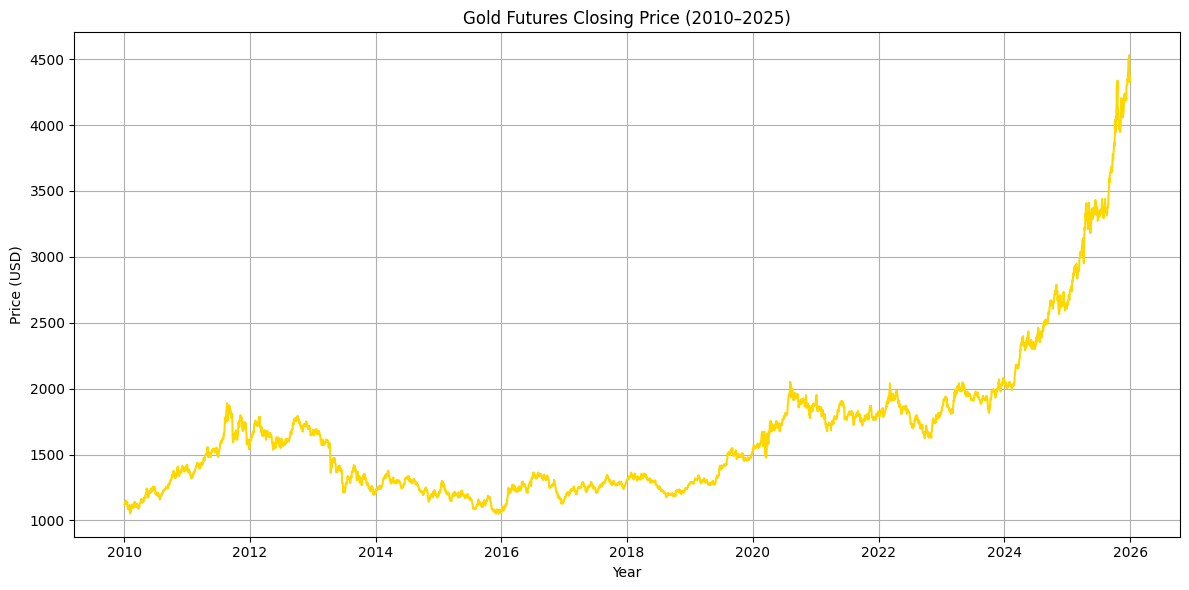

In [6]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'], color='gold')
plt.title("Gold Futures Closing Price (2010–2025)")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.grid(True)
plt.show()

Normal Distribution of Features

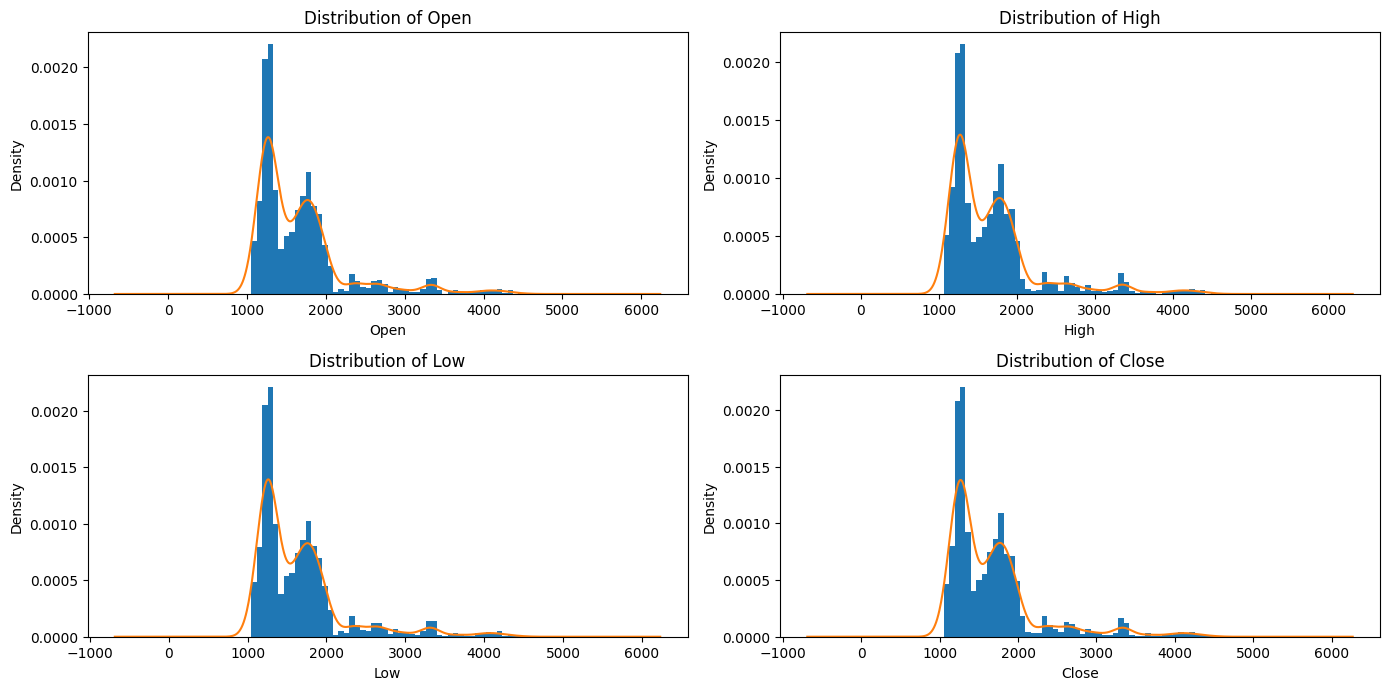

In [7]:
features = ['Open', 'High', 'Low', 'Close']

plt.figure(figsize=(14,10))

for i, col in enumerate(features, 1):
    plt.subplot(3, 2, i)
    df[col].plot(kind='hist', bins=50, density=True)
    df[col].plot(kind='density')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)

plt.tight_layout()
plt.show()


The distributions of Open, High, Low, and Close prices are right-skewed and non-normal, with multiple peaks. This reflects different market regimes over time rather than a single stable price level. The long right tail corresponds to recent years where gold prices increased sharply.

Close Price Distribution with Mean, Median & Curve

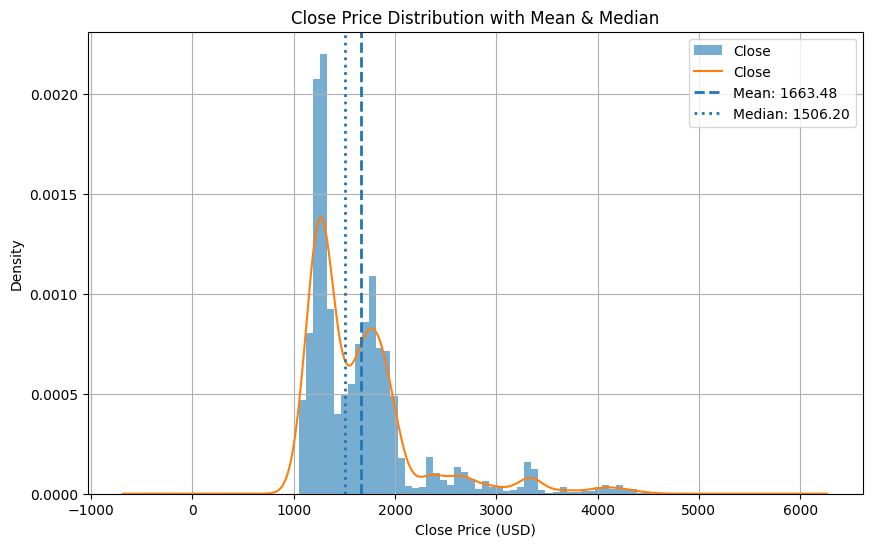

In [8]:
mean_close = df['Close'].mean()
median_close = df['Close'].median()

plt.figure(figsize=(10,6))
df['Close'].plot(kind='hist', bins=50, density=True, alpha=0.6)
df['Close'].plot(kind='density')

plt.axvline(mean_close, linestyle='--', linewidth=2, label=f"Mean: {mean_close:.2f}")
plt.axvline(median_close, linestyle=':', linewidth=2, label=f"Median: {median_close:.2f}")

plt.title("Close Price Distribution with Mean & Median")
plt.xlabel("Close Price (USD)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()


Observation
*   Mean > Median
*   Indicates right-skewness
*   A small number of very high prices pull the mean upward

Interpretation

The divergence between mean and median confirms the asymmetric distribution of gold prices, driven by recent price surges in the later years of the dataset.

Year-wise Mean CLOSE Price – BAR PLOT

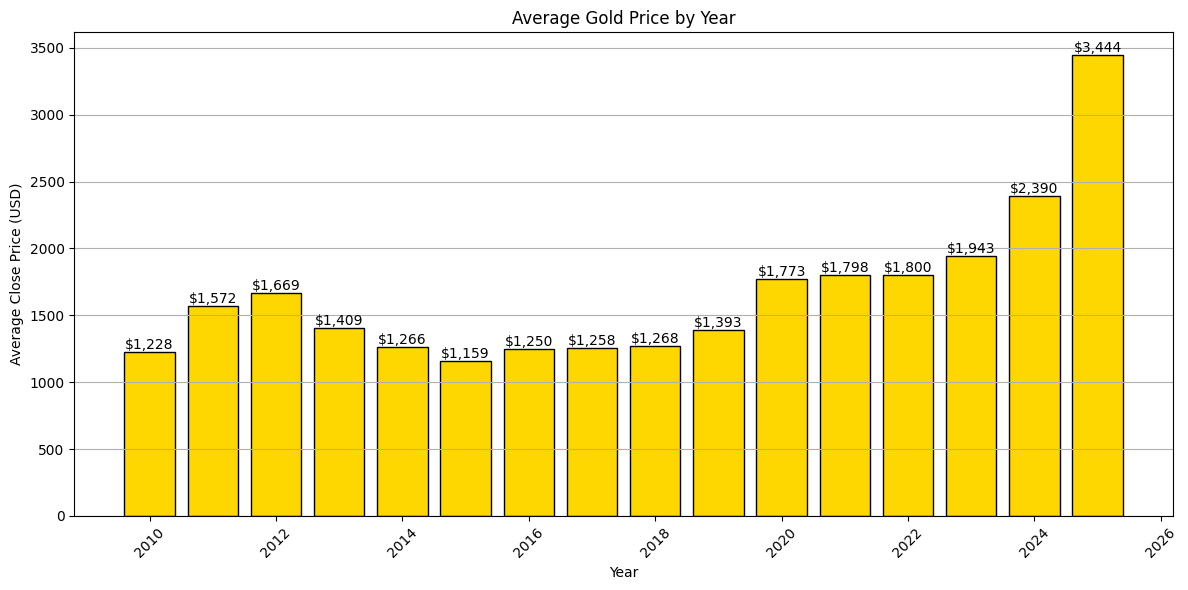

In [9]:
# Extract year from index
df['Year'] = df.index.year

# Calculate yearly average close price
yearly_mean_close = df.groupby('Year')['Close'].mean()

plt.figure(figsize=(12,6))

# Different color for Gold (golden color)
bars = plt.bar(yearly_mean_close.index,
               yearly_mean_close.values,
               color='gold',
               edgecolor='black')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"${height:,.0f}",
        ha='center',
        va='bottom'
    )

plt.title("Average Gold Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Close Price (USD)")
plt.xticks(rotation=45)

plt.grid(axis='y')
plt.tight_layout()
plt.show()

The bar plot shows a clear long-term upward trend in gold prices with distinct phases. Prices rise sharply during 2010–2012, decline and stabilise between 2013–2019, and then increase significantly from 2020 onwards. The strong acceleration after 2022 reflects heightened economic uncertainty, inflationary pressures, and increased safe-haven demand, indicating a structural shift rather than short-term fluctuation.

Time Series Analysis

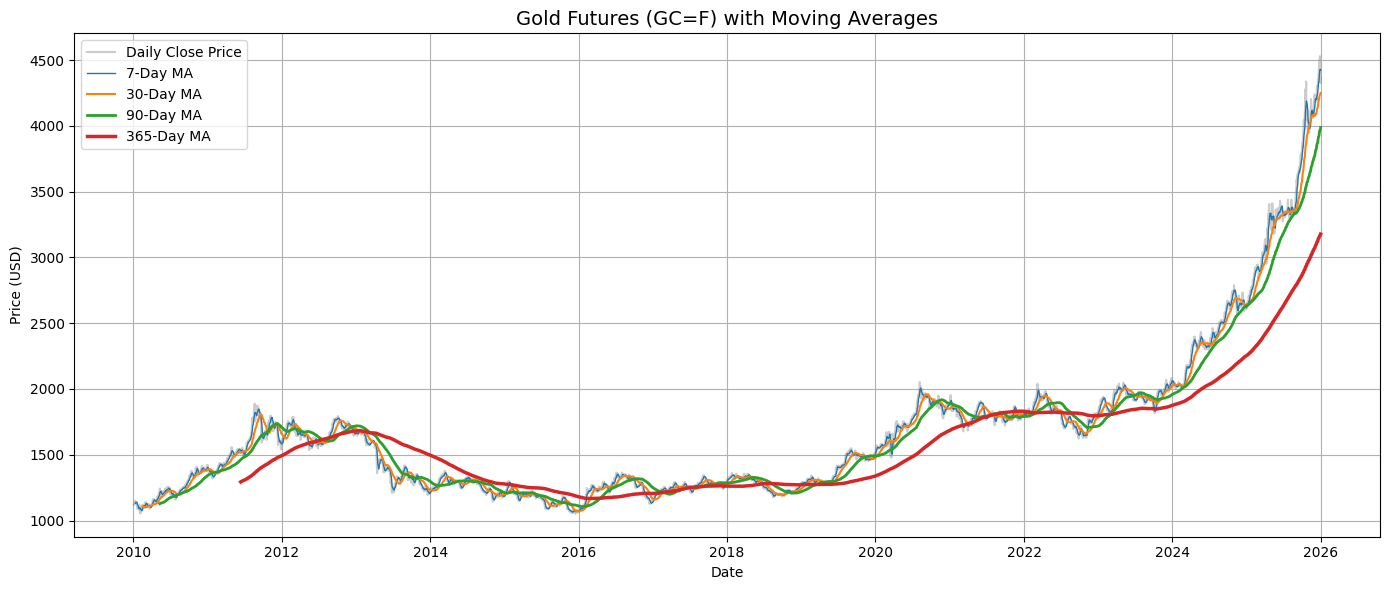

In [10]:
# Moving Averages using Close price
df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()
df['MA_90'] = df['Close'].rolling(window=90).mean()
df['MA_365'] = df['Close'].rolling(window=365).mean()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df['Close'], alpha=0.4, label='Daily Close Price', color='gray')
ax.plot(df.index, df['MA_7'], label='7-Day MA', linewidth=1)
ax.plot(df.index, df['MA_30'], label='30-Day MA', linewidth=1.5)
ax.plot(df.index, df['MA_90'], label='90-Day MA', linewidth=2)
ax.plot(df.index, df['MA_365'], label='365-Day MA', linewidth=2.5)

ax.set_title('Gold Futures (GC=F) with Moving Averages', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()

plt.tight_layout()
plt.grid(True)
plt.show()

The moving average plot of Gold Futures (GC=F) from 2010 to 2025 shows a clear long-term upward trend, particularly accelerating after 2019 and sharply increasing during 2024–2025. The 7-day and 30-day moving averages closely track short-term fluctuations, while the 90-day and 365-day moving averages highlight the broader trend. The alignment of shorter moving averages above the longer ones in recent years indicates strong bullish momentum. Overall, the series exhibits a strong non-linear trend and volatility, suggesting non-stationarity and justifying the use of differencing or return-based modelling for forecasting.

Seasonal Decomposition of Gold Futures (GC=F)

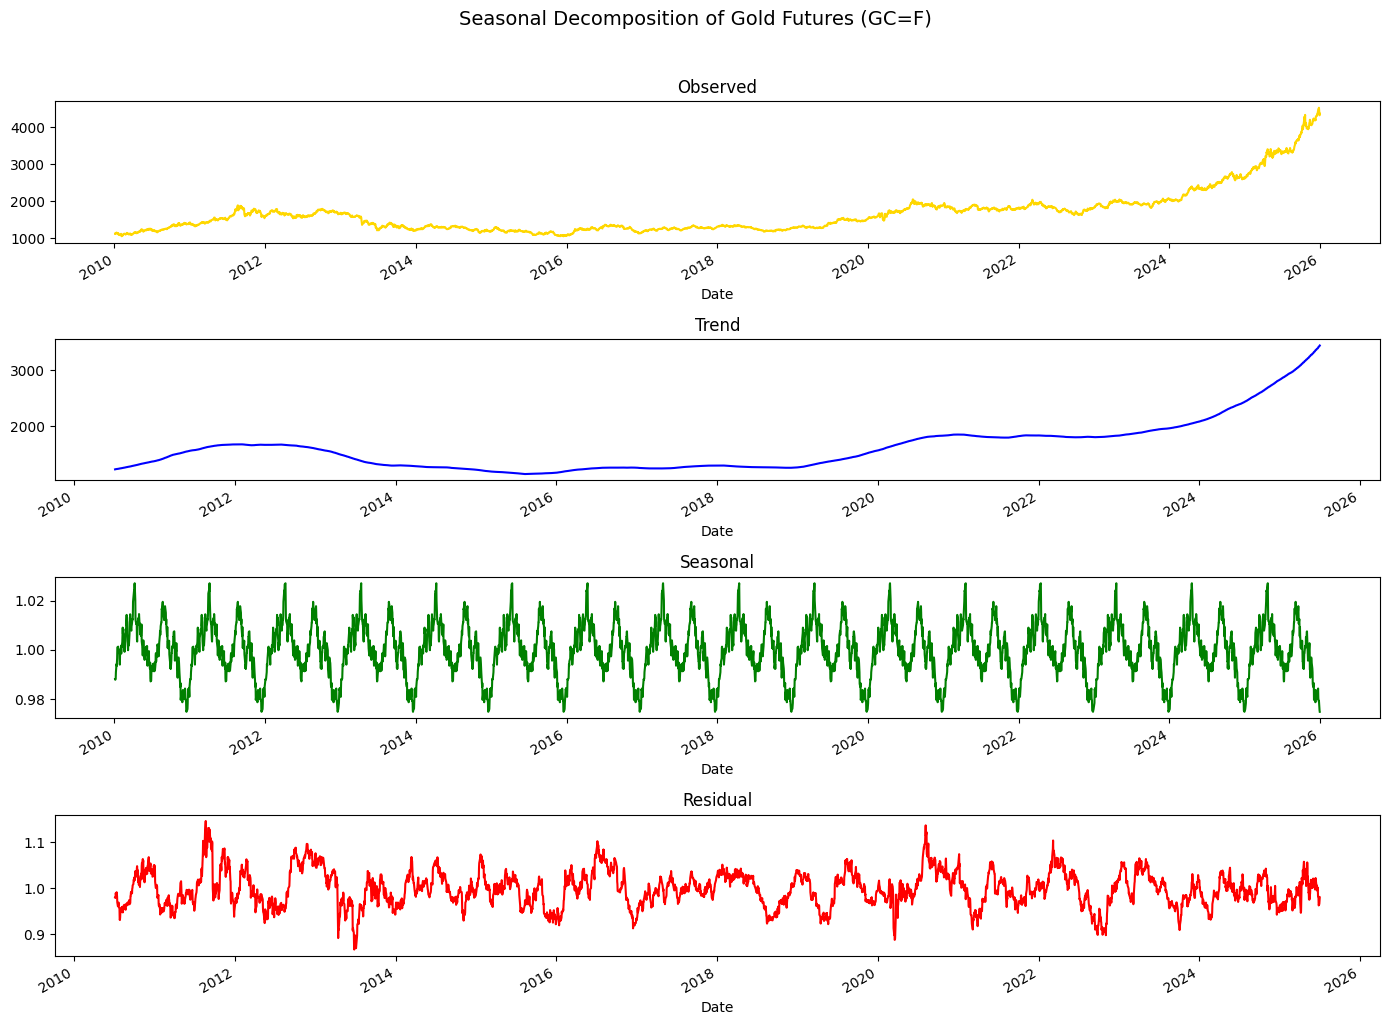

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Seasonal Decomposition using Close price
decomposition = seasonal_decompose(
    df['Close'].dropna(),
    model='multiplicative',
    period=252   # 252 trading days ≈ 1 year
)

# Plot components
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

decomposition.observed.plot(ax=axes[0], title='Observed', color='gold')
decomposition.trend.plot(ax=axes[1], title='Trend', color='blue')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal', color='green')
decomposition.resid.plot(ax=axes[3], title='Residual', color='red')

plt.suptitle('Seasonal Decomposition of Gold Futures (GC=F)',
             fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

The seasonal decomposition of Gold Futures (GC=F) shows that the observed series is dominated by a strong upward long-term trend, particularly accelerating after 2019 and sharply rising toward 2025. The trend component clearly captures this sustained growth pattern. The seasonal component fluctuates within a narrow range around 1, indicating relatively weak but consistent yearly seasonality. The residual component reflects short-term irregular fluctuations and market shocks not explained by trend or seasonality. Overall, the decomposition confirms that gold prices are primarily trend-driven with limited seasonal influence, supporting the need for differencing or return-based modelling for accurate forecasting.

Feature Engineering – Gold Futures

In [13]:
# Create Features using Close price
df['Daily_Return'] = df['Close'].pct_change() * 100

df['Volatility_7d'] = df['Daily_Return'].rolling(7).std()
df['Volatility_30d'] = df['Daily_Return'].rolling(30).std()

df['Price_Range'] = df['High'] - df['Low']

df['Month'] = df.index.month
df['DayOfWeek'] = df.index.dayofweek
df['Quarter'] = df.index.quarter


# Lag Features
for lag in [1, 7, 14, 30]:
    df[f'Close_Lag_{lag}'] = df['Close'].shift(lag)


print('Feature Engineering Complete!')
print(f'Total Features: {len(df.columns)}')
df.head()

Feature Engineering Complete!
Total Features: 21


,Close,High,Low,Open,Volume,Year,MA_7,MA_30,MA_90,MA_365,...,Volatility_7d,Volatility_30d,Price_Range,Month,DayOfWeek,Quarter,Close_Lag_1,Close_Lag_7,Close_Lag_14,Close_Lag_30
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184,2010,NaN,NaN,NaN,NaN,...,NaN,NaN,25.200073,1,0,1,NaN,NaN,NaN,NaN
2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53,2010,NaN,NaN,NaN,NaN,...,NaN,NaN,11.500000,1,1,1,1117.699951,NaN,NaN,NaN
2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363,2010,NaN,NaN,NaN,NaN,...,NaN,NaN,18.500000,1,2,1,1118.099976,NaN,NaN,NaN
2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56,2010,NaN,NaN,NaN,NaN,...,NaN,NaN,3.900024,1,3,1,1135.900024,NaN,NaN,NaN
2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54,2010,NaN,NaN,NaN,NaN,...,NaN,NaN,15.500000,1,4,1,1133.099976,NaN,NaN,NaN


Correlation Heatmap – Gold Futures

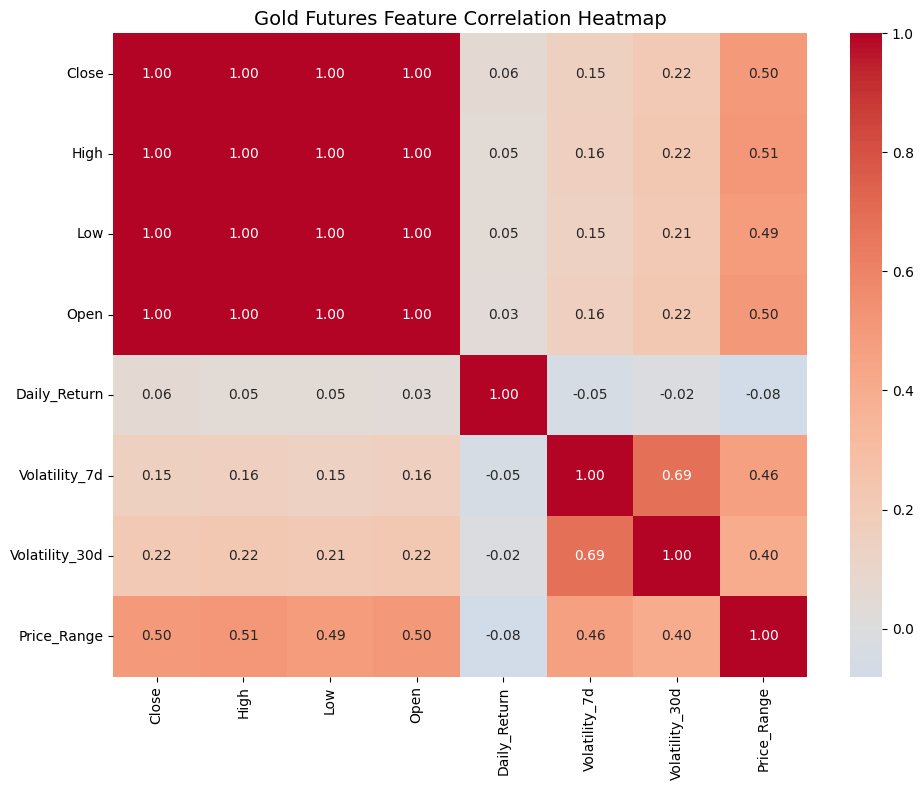

In [14]:
import seaborn as sns

# Select relevant columns
corr_cols = ['Close', 'High', 'Low', 'Open',
             'Daily_Return', 'Volatility_7d', 'Volatility_30d',
             'Price_Range']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    ax=ax
)

ax.set_title('Gold Futures Feature Correlation Heatmap',
             fontsize=14)

plt.tight_layout()
plt.show()

The correlation heatmap shows that the core price variables (Close, Open, High, and Low) are almost perfectly positively correlated (≈1.00), indicating strong multicollinearity since they represent similar price information. Daily_Return has very weak correlation with price levels, confirming that returns are largely independent of absolute price values. Volatility_7d and Volatility_30d exhibit a strong positive correlation (≈0.69), as both measure rolling risk over different windows. Price_Range shows moderate positive correlation with price levels and volatility, suggesting that larger daily movements are associated with higher market volatility. Overall, the heatmap highlights redundancy among price variables and supports the use of engineered features such as returns and volatility for predictive modelling.

Random Forest Regressor Model

Random Forest Results
RMSE: 936.3346052043541
MAE: 640.7393067972882
R2: -0.7893964162320146
MAPE: 19.830593308468195


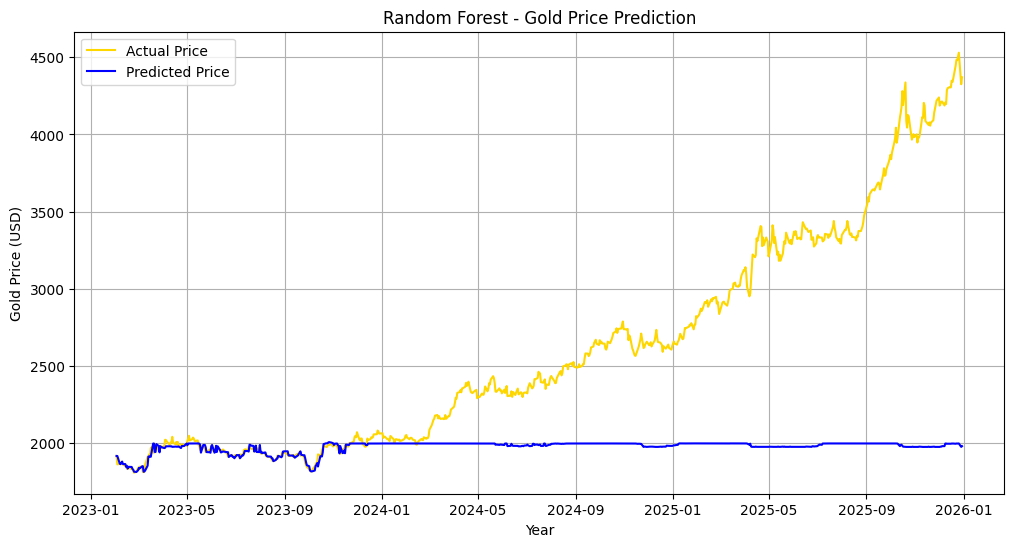

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Remove rows with NaN values from lag and rolling features
df_model = df.dropna()

# Features
features = [
    'Close_Lag_1',
    'Close_Lag_7',
    'Close_Lag_14',
    'Close_Lag_30',
    'Volatility_30d',
    'Price_Range',
    'Month'
]

# Define X and y
X = df_model[features]
y = df_model['Close']

# Time-based split
split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Train model
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=5,
    random_state=123
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("Random Forest Results")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("MAPE:", mape)

# Plot Actual vs Predicted
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label="Actual Price", color='gold')
plt.plot(y_test.index, y_pred, label="Predicted Price", color='blue')

plt.title("Random Forest - Gold Price Prediction")
plt.xlabel("Year")
plt.ylabel("Gold Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

The Random Forest model performed poorly in predicting gold closing prices, as indicated by the negative R² value (-0.79) and high RMSE and MAPE. The predicted values remain nearly flat around the historical average, while the actual gold prices show a strong upward trend, especially during 2024–2025. This failure occurs because Random Forest is a tree-based model that performs well at interpolation within the training range but struggles with extrapolation beyond previously observed values. Since gold prices experienced a sharp structural increase in the test period, the model was unable to generalise this new trend and instead predicted values close to earlier historical levels.

Furthermore, financial time series such as gold prices are highly non-linear, non-stationary, and influenced by macroeconomic shocks, which makes direct price-level prediction challenging for traditional machine learning models. Although lag and volatility features were included, the strong upward trend dominated the series, and Random Forest could not inherently model temporal dynamics in the same way as time-series-specific methods. This demonstrates that tree-based models are not well-suited for forecasting trending financial price levels

Train XGBoost Model

In [16]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=123
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

Predictions

In [17]:
y_pred_xgb = xgb_model.predict(X_test)

Evaluation Metrics

In [18]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae = mean_absolute_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)
mape = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100

print("XGBoost Results")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("MAPE:", mape)

XGBoost Results
RMSE: 967.8564955922228
MAE: 671.6044835158384
R2: -0.9119051920274219
MAPE: 20.939483619965493


The XGBoost regression model was applied to predict gold closing prices using lag features, volatility indicators, trading range, and calendar-based variables. XGBoost is a gradient boosting algorithm that sequentially builds decision trees to reduce prediction errors and capture complex non-linear relationships in the data. Compared to Random Forest, XGBoost often provides better performance because it optimizes the learning process through gradient boosting and regularization techniques.

However, similar to Random Forest, XGBoost also faces challenges when predicting strongly trending financial time series because tree-based models are primarily designed for interpolation rather than extrapolation. Although the model may capture short-term fluctuations better than Random Forest, it still struggles to fully reproduce the strong upward trend observed in gold prices during the later years of the dataset.

LSTM Model Implementation

Import Libraries for LSTM Model

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input


import random
np.random.seed(43)
tf.random.set_seed(43)
random.seed(43)

Prepare Data (Use Close Price Only)

In [20]:
data = df[['Close']].copy()

Scale Data

In [21]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

Create Time Sequences (120 days window)

In [22]:
def create_sequences(data, window=120):

    X = []
    y = []

    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])

    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, window=120)

Train-Test Split (80/20)

In [23]:
split_index = int(len(X) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

Reshape for LSTM

LSTM expects 3D input:

(samples, time_steps, features)

In [24]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

Build LSTM Model

In [25]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1],1)))

model.add(LSTM(50, return_sequences=True))
model.add(Dropout(0.2, seed=43))

model.add(LSTM(50))
model.add(Dropout(0.2, seed=43))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

Train Model

In [26]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0010 - val_loss: 1.3347e-04
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.2372e-04 - val_loss: 1.5108e-04
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.1693e-04 - val_loss: 1.1829e-04
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8484e-04 - val_loss: 1.1285e-04
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.6211e-04 - val_loss: 1.3709e-04
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.5054e-04 - val_loss: 8.6822e-05
Epoch 7/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.5162e-04 - val_loss: 8.4232e-05
Epoch 8/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.3963e-04 - val_loss: 1.0202e-04
Epoch 9/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.3185e-04 - val_loss: 8.3940e-05
Epoch 10/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.2737e-04 - val_loss: 9.7062e-05
Epoch 11/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1787e-04 - 

Make Predictions

In [27]:
predictions = model.predict(X_test)

# Reverse scaling
predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


Evaluation Metrics

In [28]:
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mae = mean_absolute_error(y_test_actual, predictions)
r2 = r2_score(y_test_actual, predictions)
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

print("LSTM Performance")
print("RMSE :", rmse)
print("MAE  :", mae)
print("MAPE :", mape)
print("R²   :", r2)

LSTM Performance
RMSE : 86.80521669487032
MAE  : 62.59227359004877
MAPE : 2.172679998251766
R²   : 0.9847812075642886


Plot Actual vs Predicted

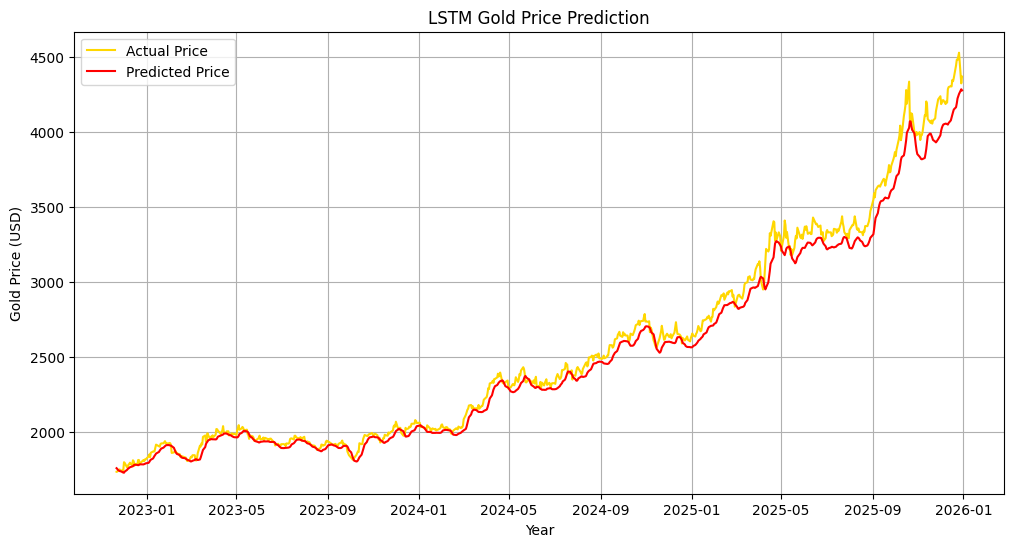

In [29]:
plt.figure(figsize=(12,6))

plt.plot(df.index[-len(y_test_actual):], y_test_actual, label="Actual Price", color="gold")
plt.plot(df.index[-len(predictions):], predictions, label="Predicted Price", color="red")

plt.title("LSTM Gold Price Prediction")
plt.xlabel("Year")
plt.ylabel("Gold Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

3-Month Gold Price Forecast using LSTM

In [30]:
future_days = 60   # approx 2 months of trading days

Take the last 60 days from the dataset

The model needs previous 60 days input to predict the next value.

In [31]:
last_sequence = scaled_data[-60:]

Reshape for LSTM

In [32]:
last_sequence = last_sequence.reshape(1, 60, 1)

Generate Future Predictions

In [33]:
future_predictions = []

current_sequence = last_sequence.copy()

for i in range(future_days):

    next_pred = model.predict(current_sequence, verbose=0)

    # store prediction
    future_predictions.append(next_pred[0,0])

    # reshape prediction correctly
    next_pred = next_pred.reshape(1,1,1)

    # update sequence
    current_sequence = np.concatenate(
        (current_sequence[:,1:,:], next_pred),
        axis=1
    )

Convert Predictions Back to Original Price Scale

In [34]:
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

Create Future Dates

In [35]:
last_date = df.index[-1]

future_dates = pd.date_range(
    start=last_date,
    periods=future_days+1,
    freq='B'
)[1:]

Plot Forecast

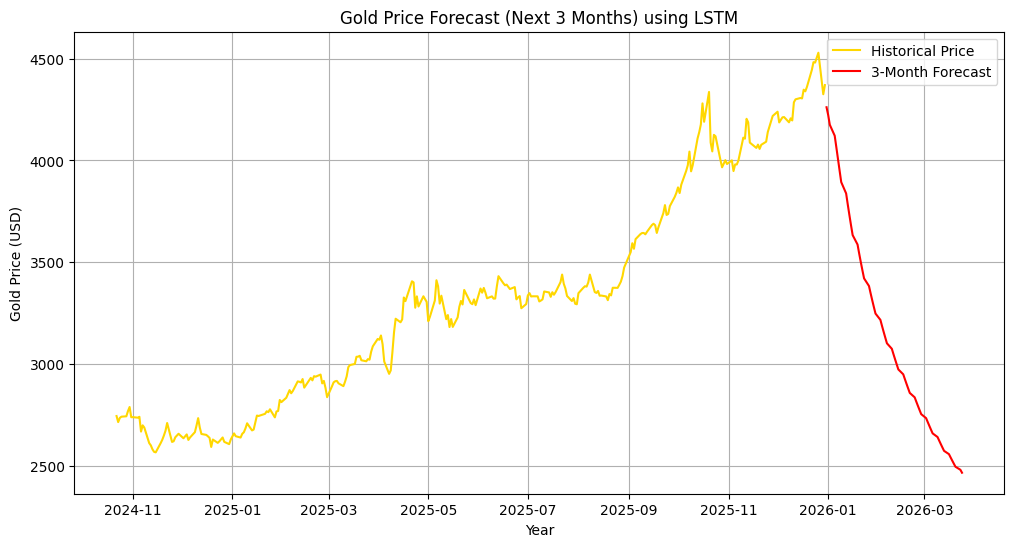

In [36]:
plt.figure(figsize=(12,6))

plt.plot(df.index[-300:], df['Close'][-300:], label="Historical Price", color='gold')
plt.plot(future_dates, future_predictions, label="3-Month Forecast", color='red')

plt.title("Gold Price Forecast (Next 3 Months) using LSTM")
plt.xlabel("Year")
plt.ylabel("Gold Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

**Model Performance Comparison**

The performance of Random Forest, XGBoost, and LSTM models was evaluated using the R² metric. The Random Forest and XGBoost models produced negative R² values, indicating that these models were unable to effectively capture the underlying patterns in the gold price time series. This suggests that traditional tree-based machine learning models struggle to model the strong temporal dependencies and trends present in financial data.

In contrast, the LSTM model achieved a very high R² value, demonstrating its ability to accurately capture the sequential structure and long-term dependencies in the gold price series. This highlights the advantage of deep learning approaches, particularly recurrent neural networks, for time series forecasting tasks.

**Next Step**

In the next stage, a **tuned LSTM model** will be implemented by adjusting key hyperparameters such as the number of units, dropout rate, epochs, and lookback window to further improve the model’s predictive performance and forecasting stability.


#Tuned LSTM

Key Improvements:

- More LSTM units (50 → 100)

- Better dropout balance

- More epochs (50)

- EarlyStopping

- Learning rate control

Build Tuned LSTM

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

tuned_model = Sequential()

# Layer 1
tuned_model.add(LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], 1)))
tuned_model.add(Dropout(0.3))

# Layer 2
tuned_model.add(LSTM(64, return_sequences=True))
tuned_model.add(Dropout(0.3))

# Layer 3 (NEW)
tuned_model.add(LSTM(32))
tuned_model.add(Dropout(0.2))

# Dense layers
tuned_model.add(Dense(25, activation='relu'))
tuned_model.add(Dense(1))

optimizer = Adam(learning_rate=0.0005)

tuned_model.compile(
    optimizer=optimizer,
    loss='mean_squared_error'
)

tuned_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 120, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 120, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │           825 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,235 (504.82 KB)

 Trainable params: 129,235 (504.82 KB)

 Non-trainable params: 0 (0.00 B)

Early Stopping

In [38]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

Train Model

In [39]:
history = tuned_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0011 - val_loss: 3.6357e-04
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 3.2045e-04 - val_loss: 2.3500e-04
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 2.6531e-04 - val_loss: 1.6997e-04
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 2.1702e-04 - val_loss: 2.7079e-04
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 1.8863e-04 - val_loss: 2.0844e-04
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 1.8381e-04 - val_loss: 1.7012e-04
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.7307e-04 - val_loss: 1.6810e-04
Epoch 8/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 1.5952e-04 - val_loss: 1.2691e-04
Epoch 9/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 1.5243e-04 - val_loss: 1.1948e-04
Epoch 10/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.5112e-04 - val_loss: 1.4194e-04
Epoch 11/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 1.3776e-04 - 

Predictions

In [40]:
tuned_predictions = tuned_model.predict(X_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


Scaling

In [41]:
tuned_predictions = scaler.inverse_transform(tuned_predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

Metrics

In [42]:
rmse = np.sqrt(mean_squared_error(y_test_actual, tuned_predictions))
mae = mean_absolute_error(y_test_actual, tuned_predictions)
r2 = r2_score(y_test_actual, tuned_predictions)
mape = np.mean(np.abs((y_test_actual - tuned_predictions) / y_test_actual)) * 100

print("Tuned LSTM Model Performance")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Tuned LSTM Model Performance
Root Mean Squared Error (RMSE): 162.14
Mean Absolute Error (MAE): 105.68
R-squared (R²): 0.9469
Mean Absolute Percentage Error (MAPE): 3.39%


Actual vs Predicted Plot(Tuned LSTM)

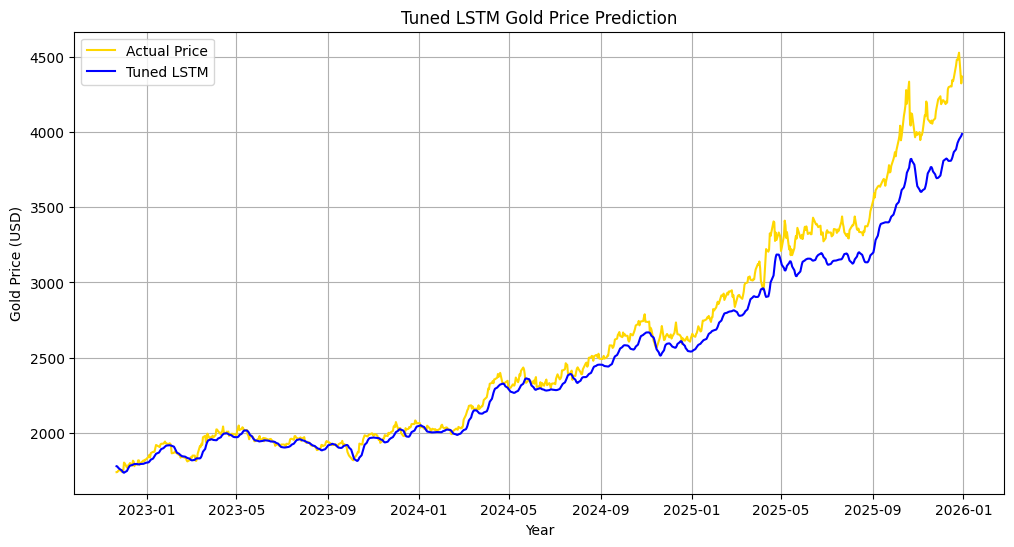

In [43]:
plt.figure(figsize=(12,6))

plt.plot(df.index[-len(y_test_actual):], y_test_actual, label="Actual Price", color="gold")
plt.plot(df.index[-len(tuned_predictions):], tuned_predictions, label="Tuned LSTM", color="blue")

plt.title("Tuned LSTM Gold Price Prediction")
plt.xlabel("Year")
plt.ylabel("Gold Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

Tuned LSTM Forecast (3 Months)

In [44]:
future_days = 60   # 3 months

Take Last Sequence

In [45]:
last_sequence = scaled_data[-60:]
last_sequence = last_sequence.reshape(1, 60, 1)

Generate Future Predictions

In [46]:
future_predictions = []

current_sequence = last_sequence.copy()

for i in range(future_days):

    next_pred = tuned_model.predict(current_sequence, verbose=0)

    # store prediction
    future_predictions.append(next_pred[0,0])

    # reshape properly
    next_pred = next_pred.reshape(1,1,1)

    # update sequence (rolling window)
    current_sequence = np.concatenate(
        (current_sequence[:,1:,:], next_pred),
        axis=1
    )

Convert Back to Original Scale

In [47]:
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

Create Future Dates

In [48]:
last_date = df.index[-1]

future_dates = pd.date_range(
    start=last_date,
    periods=future_days + 1,
    freq='B'   # business days
)[1:]

Plot Forecast

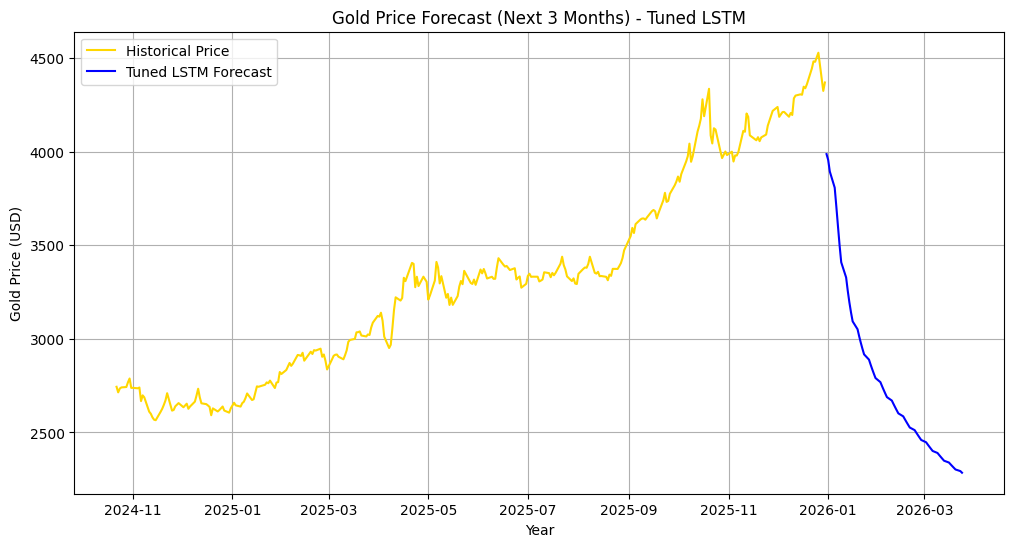

In [49]:
plt.figure(figsize=(12,6))

plt.plot(df.index[-300:], df['Close'][-300:], label="Historical Price", color='gold')
plt.plot(future_dates, future_predictions, label="Tuned LSTM Forecast", color='blue')

plt.title("Gold Price Forecast (Next 3 Months) - Tuned LSTM")
plt.xlabel("Year")
plt.ylabel("Gold Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

# Model Performance Summary

The performance of different models was evaluated using RMSE, MAE, MAPE, and R².

- Random Forest and XGBoost models performed poorly, producing nearly constant predictions and failing to capture the strong upward trend in gold prices.
- The base LSTM model achieved excellent performance with a low RMSE of 86.81, MAE of 62.59, MAPE of 2.17%, and a high R² value of 0.98.
- A tuned LSTM model was also implemented with increased complexity and additional layers. However, this model resulted in worse performance, with higher RMSE (162.14) and lower R² (0.94).

This indicates that increasing model complexity does not always improve performance and may lead to overfitting or reduced generalisation.

# Discussion on Model Complexity

Although the tuned LSTM model incorporated more layers and parameters, it did not outperform the base LSTM model. This suggests that the simpler architecture was better suited for the given dataset.

The decline in performance may be attributed to:
- Overfitting due to increased model complexity
- Insufficient data to support deeper architectures
- Increased noise sensitivity

This highlights the importance of selecting an optimal model rather than a more complex one.

#  Future Forecast using LSTM Model

The LSTM model is used to generate multi-step future predictions for gold prices over the next 60 trading days.

A recursive forecasting strategy is applied, where each predicted value is iteratively used as input for subsequent predictions. This approach allows the model to simulate real-world forecasting scenarios.

The results are presented in tabular format for better interpretability and analysis.

In [53]:
future_days = 60

# Last 60 days
last_sequence = scaled_data[-60:]
last_sequence = last_sequence.reshape(1, 60, 1)

future_predictions = []

current_sequence = last_sequence.copy()

for i in range(future_days):

    next_pred = model.predict(current_sequence, verbose=0)

    future_predictions.append(next_pred[0,0])

    next_pred = next_pred.reshape(1,1,1)

    current_sequence = np.concatenate(
        (current_sequence[:,1:,:], next_pred),
        axis=1
    )

# Convert back
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

In [55]:
future_dates = pd.date_range(
    start=df.index[-1],
    periods=future_days + 1,
    freq='B'
)[1:]

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Price': future_predictions.flatten()
})

forecast_df.set_index('Date', inplace=True)

print("\n Forecast Generated using LSTM Model")
print(" Duration: Next 60 Trading Days")

print(forecast_df.head(60))


 Forecast Generated using LSTM Model
 Duration: Next 60 Trading Days
            Predicted_Price
Date                       
2025-12-31      4261.277832
2026-01-01      4223.331055
2026-01-02      4175.106934
2026-01-05      4121.416992
2026-01-06      4065.015381
2026-01-07      4007.560547
2026-01-08      3950.113037
2026-01-09      3893.382324
2026-01-12      3837.857666
2026-01-13      3783.878174
2026-01-14      3731.668945
2026-01-15      3681.369873
2026-01-16      3633.050781
2026-01-19      3586.727051
2026-01-20      3542.369873
2026-01-21      3499.918457
2026-01-22      3459.286377
2026-01-23      3420.371826
2026-01-26      3383.062500
2026-01-27      3347.242188
2026-01-28      3312.794189
2026-01-29      3279.605713
2026-01-30      3247.569336
2026-02-02      3216.585938
2026-02-03      3186.563965
2026-02-04      3157.421631
2026-02-05      3129.087646
2026-02-06      3101.497559
2026-02-09      3074.596924
2026-02-10      3048.338867
2026-02-11      3022.683105
2026-0

# Conclusion

This study investigated the use of machine learning and deep learning models for forecasting gold prices using historical time series data.

Exploratory analysis revealed that gold prices exhibit strong trends, non-linearity, and non-stationary behaviour, making prediction a complex task. Traditional machine learning models such as Random Forest and XGBoost failed to capture these temporal dynamics and produced poor predictive results.

In contrast, the LSTM model demonstrated superior performance, achieving a high R² value of 0.98 and low prediction errors. This highlights its ability to effectively model sequential dependencies and long-term patterns in financial data.

A more complex tuned LSTM model was also implemented; however, it did not outperform the base LSTM model. This indicates that increasing model complexity does not always lead to better performance and may result in overfitting.

The final LSTM model was used to generate future forecasts, which showed a consistent continuation of historical trends. Overall, the study demonstrates that LSTM is a powerful and reliable approach for financial time series forecasting.